In [12]:
# ===================================
# 1. 멀티스레딩을 이용한 로그 파일 병렬 읽기
# 2. 단일 쓰레드 vs 멀티 쓰레드 처리시간을 비교
# ===================================

In [24]:
import os
import time
import concurrent.futures
import matplotlib.pyplot as plt

In [25]:
LOG_DIR = './자료/log_files'
os.makedirs(LOG_DIR, exist_ok=True)

for i in range(10000):
    file_path = os.path.join(LOG_DIR, f'log_{i}.txt')
    if not os.path.exists(file_path):
        with open(file_path, 'w', encoding='utf-8') as f:
            f.write(('Sensor Value : ' + str(i) + '\n') * 10000)

files = [os.path.join(LOG_DIR,f) for f in os.listdir(LOG_DIR)]

In [28]:
# 파일 읽어오기
def read_file(path: str) -> str:
    with open(path, 'r', encoding='utf-8') as f:    # 읽기 모드로 파일 불러오기
        content = f.read()    # 파일 전체 내용 읽어오기
    return content            # 읽은 내용을 호출한 쪽에 반환

# 단일 쓰레드
start_single = time.time()   # 단일 쓰레드 방식 시작 시간 측정
for path_ in files:          # 파일은 슨차적으로 읽어옴
    _ = read_file(path_)
end_single = time.time()     
elapsed_single = end_single - start_single # 걸린 시간 계산

print(f"단일 쓰레드 처리시간 : {elapsed_single:.4f}초")

단일 쓰레드 처리시간 : 4.0927초


In [29]:
# 멀티 쓰레드
start_multi = time.time()

with concurrent.futures.ThreadPoolExecutor() as excutor:
    list(excutor.map(read_file, files)) # executor.map으로 read_file 함수를 file 목록에 병렬로 적용
end_multi = time.time()
elapsed_multi = end_multi - start_multi

print(f'멀티 쓰레드 처리시간 : {elapsed_multi:.4f}초')

멀티 쓰레드 처리시간 : 6.0313초


ValueError: Format specifier missing precision

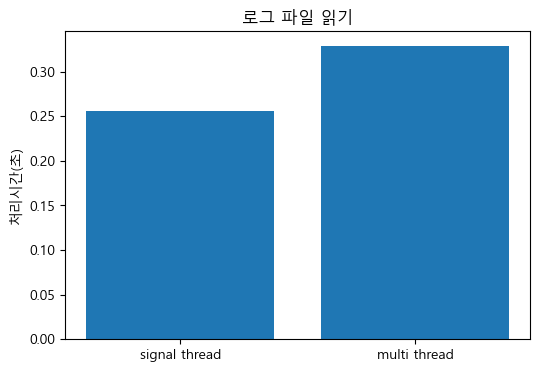

In [17]:
# 그래프 출력
from matplotlib import font_manager, rc #한글 폰트 지정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 성능 비교 시각화
labels = ['signal thread', 'multi thread']
times = [elapsed_single, elapsed_multi]

plt.figure(figsize=(6,4))
plt.bar(labels, times)
plt.ylabel('처리시간(초)')
plt.title('로그 파일 읽기')

for i, v in enumerate(times):
    plt.text(i, v, f'{v:3.f} s',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [30]:
import os
print(f"CPU 코어 수: {os.cpu_count()}개")

CPU 코어 수: 12개


In [33]:
import requests
import time
import concurrent.futures

# 1초 걸리는 URL 10개
urls = ["https://httpbin.org/delay/1"] * 10

def fetch_url(url):
    return requests.get(url)

# 단일 쓰레드
start_single = time.time()
for url in urls:
    fetch_url(url)
end_single = time.time()
print(f"단일 쓰레드: {end_single - start_single:.4f}초")  # 약 10초

# 멀티 쓰레드
start_multi = time.time()
with concurrent.futures.ThreadPoolExecutor() as executor:
    list(executor.map(fetch_url, urls))
end_multi = time.time()
print(f"멀티 쓰레드: {end_multi - start_multi:.4f}초")  # 약 1~2초

## 예상 결과

단일 쓰레드: 34.5633초
멀티 쓰레드: 9.5893초
